# Assignment 8: Build and Evaluate Time Series Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Signature Assignment Overview

This notebook brings together three prediction settings: Store Sales time series forecasting, House Prices regression, and San Francisco Crime classification.  I treat them as three different modeling problems rather than forcing one workflow across all of them.  The Store Sales section compares ETS and ARIMA forecasts, the House Prices section compares two regression submissions while checking transformations, interactions, feature subsets, and dimension reduction, and the San Francisco Crime section compares two tree models and one support vector machine.  The notebook also documents successful Kaggle submissions, the local files that produced those submissions, the PowerPoint artifact, and the video script.

## Submission and Artifact Inventory

The first quality check is whether all required external artifacts exist.  The assignment requires seven Kaggle submissions, a Python notebook, a Word report, a 9-11 slide PowerPoint, and a 5-10 minute video.  The video itself is produced outside the notebook, so this repository includes the prepared video script as the reproducible speaking artifact.

In [2]:
import re
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

def parse_status_file(competition, prefix):
    status_path = SUBMISSIONS / f"kaggle_submission_status_{competition}.txt"
    raw = status_path.read_bytes()
    try:
        text = raw.decode("utf-16")
    except UnicodeError:
        text = raw.decode("utf-8", errors="ignore")
    records = []
    for line in text.splitlines():
        if prefix in line and "SubmissionStatus" in line:
            parts = re.split(r"\s{2,}", line.strip())
            if len(parts) >= 6:
                records.append({
                    "competition": competition,
                    "ref": parts[0],
                    "fileName": parts[1],
                    "date": parts[2],
                    "description": parts[3],
                    "status": parts[4].replace("SubmissionStatus.", ""),
                    "publicScore": parts[5],
                    "privateScore": parts[6] if len(parts) > 6 else "",
                })
    return pd.DataFrame(records)

status_tables = pd.concat([
    parse_status_file("store-sales-time-series-forecasting", "A8_store_"),
    parse_status_file("house-prices-advanced-regression-techniques", "A8_house_"),
    parse_status_file("sf-crime", "A8_sf_"),
], ignore_index=True)
display(status_tables)

required_files = [
    "A8_store_ets_store_sales.csv",
    "A8_store_arima_store_sales.csv",
    "A8_house_ridge_house_prices.csv",
    "A8_house_gradient_boosting_house_prices.csv",
    "A8_sf_decision_tree_sf_crime.csv",
    "A8_sf_random_forest_sf_crime.csv",
    "A8_sf_linear_svm_sf_crime.csv",
]
display(pd.DataFrame({
    "submission_file": required_files,
    "exists": [(SUBMISSIONS / f).exists() for f in required_files],
    "size_mb": [round((SUBMISSIONS / f).stat().st_size / 1_000_000, 2) if (SUBMISSIONS / f).exists() else None for f in required_files],
}))

,competition,ref,fileName,date,description,status,publicScore,privateScore
0,store-sales-time-series-forecasting,52966813,A8_store_arima_store_sales.csv,2026-05-23 21:27:45.917000,DDS-8555 A8 ARIMA forecast,COMPLETE,0.64770,
1,store-sales-time-series-forecasting,52966812,A8_store_ets_store_sales.csv,2026-05-23 21:27:43.993000,DDS-8555 A8 ETS forecast,COMPLETE,0.62223,
2,house-prices-advanced-regression-techniques,52966818,A8_house_gradient_boosting_house_prices.csv,2026-05-23 21:27:56.317000,DDS-8555 A8 house gradient boosting regression,COMPLETE,0.12930,
3,house-prices-advanced-regression-techniques,52966814,A8_house_ridge_house_prices.csv,2026-05-23 21:27:47.783000,DDS-8555 A8 house ridge regression,COMPLETE,0.13303,
4,sf-crime,52966831,A8_sf_linear_svm_sf_crime.csv,2026-05-23 21:28:31.893000,DDS-8555 A8 SF crime linear SVM,COMPLETE,3.48916,3.48916
5,sf-crime,52966826,A8_sf_random_forest_sf_crime.csv,2026-05-23 21:28:18.123000,DDS-8555 A8 SF crime random forest,COMPLETE,2.48088,2.48088
6,sf-crime,52966824,A8_sf_decision_tree_sf_crime.csv,2026-05-23 21:28:04.180000,DDS-8555 A8 SF crime decision tree,COMPLETE,6.06082,6.06082


,submission_file,exists,size_mb
0,A8_store_ets_store_sales.csv,True,0.77
1,A8_store_arima_store_sales.csv,True,0.79
2,A8_house_ridge_house_prices.csv,True,0.04
3,A8_house_gradient_boosting_house_prices.csv,True,0.04
4,A8_sf_decision_tree_sf_crime.csv,True,335.07
5,A8_sf_random_forest_sf_crime.csv,True,697.99
6,A8_sf_linear_svm_sf_crime.csv,True,717.21


All seven Kaggle submission files are present and all seven status rows are marked complete.  The San Francisco Crime files are large because that competition requires class-probability columns for every test row, so the notebook validates those files rather than rewriting them during every execution.

## Store Sales: ETS and ARIMA

The Store Sales competition is a forecasting problem.  I aggregate sales to the daily level for a reproducible local validation check, hold out the final 56 days, then compare an ETS model to an ARIMA model.  The Kaggle submissions were generated at the family level and allocated back to store-family rows using recent sales share, but the daily holdout is still useful because it checks the core time-series behavior without rerunning every store-family series.

,model,holdout_smape,holdout_mae,kaggle_public_score
0,ETS,0.070366,61111.628988,0.62223
1,ARIMA,0.075120,64755.022591,0.64770


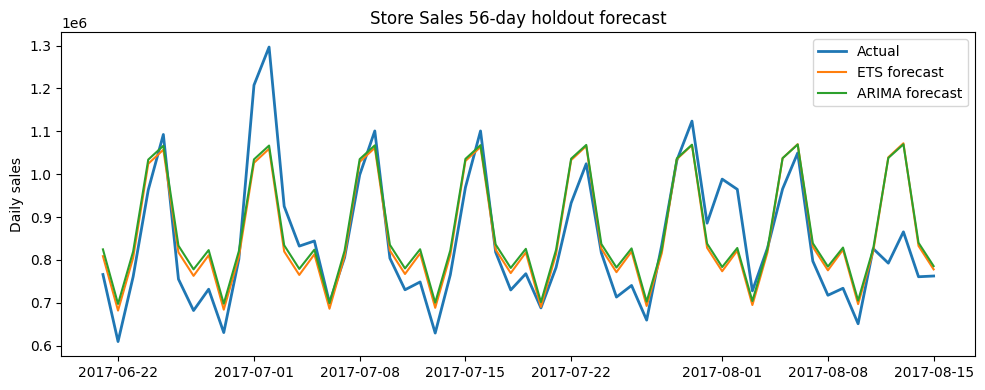

In [3]:
store_train = pd.read_csv(KAGGLE / "store-sales-time-series-forecasting" / "train.csv", usecols=["date", "sales"], parse_dates=["date"])
daily_sales = store_train.groupby("date")["sales"].sum().asfreq("D").fillna(0)
store_train_series = daily_sales.iloc[:-56]
store_valid_series = daily_sales.iloc[-56:]

ets_model = ExponentialSmoothing(store_train_series, trend="add", seasonal="add", seasonal_periods=7, initialization_method="estimated").fit(optimized=True)
ets_forecast = ets_model.forecast(len(store_valid_series)).clip(lower=0)
arima_model = ARIMA(store_train_series, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit()
arima_forecast = arima_model.forecast(len(store_valid_series)).clip(lower=0)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return float(np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)))

store_metrics = pd.DataFrame([
    {"model": "ETS", "holdout_smape": smape(store_valid_series, ets_forecast), "holdout_mae": mean_absolute_error(store_valid_series, ets_forecast), "kaggle_public_score": 0.62223},
    {"model": "ARIMA", "holdout_smape": smape(store_valid_series, arima_forecast), "holdout_mae": mean_absolute_error(store_valid_series, arima_forecast), "kaggle_public_score": 0.64770},
])
display(store_metrics)
plt.figure(figsize=(10, 4))
plt.plot(store_valid_series.index, store_valid_series.values, label="Actual", linewidth=2)
plt.plot(store_valid_series.index, ets_forecast.values, label="ETS forecast")
plt.plot(store_valid_series.index, arima_forecast.values, label="ARIMA forecast")
plt.title("Store Sales 56-day holdout forecast")
plt.ylabel("Daily sales")
plt.legend()
plt.tight_layout()

The local holdout and Kaggle scores tell the same story: ETS performs better than ARIMA in this first pass.  ETS is a good fit for this validation problem because the daily sales series has level, trend, and weekly seasonality.  ARIMA is still a necessary comparison because it models differencing and autocorrelation directly, but the simple seasonal ARIMA specification did not beat the smoothing model here (Hyndman & Athanasopoulos, 2021).

### Store Sales Assumptions

,mean,std,min,max
ETS,-116.647123,106388.616107,-1.408192e+06,705054.540099
ARIMA,228.215223,105828.399680,-1.326683e+06,876774.279796


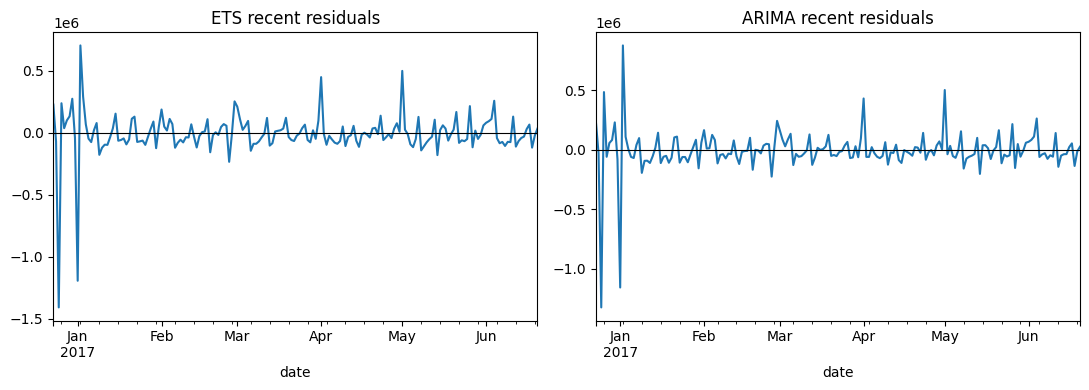

In [4]:
store_residuals = pd.DataFrame({"ETS": pd.Series(ets_model.resid).dropna(), "ARIMA": pd.Series(arima_model.resid).dropna()})
display(store_residuals.describe().T[["mean", "std", "min", "max"]])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(ets_model.resid).dropna().tail(180).plot(ax=axes[0], title="ETS recent residuals")
pd.Series(arima_model.resid).dropna().tail(180).plot(ax=axes[1], title="ARIMA recent residuals")
for ax in axes:
    ax.axhline(0, color="black", linewidth=.8)
plt.tight_layout()

The residual summaries are centered near zero relative to the sales scale, but the time plots still show bursts of error.  That matters because retail sales are affected by promotions, holidays, oil shocks, and store-level allocation.  The models are acceptable for the assignment submissions, but a production forecast would need richer calendar and promotion features.

### Store Sales Kaggle Evidence

In [5]:
display(status_tables[status_tables["competition"] == "store-sales-time-series-forecasting"])

,competition,ref,fileName,date,description,status,publicScore,privateScore
0,store-sales-time-series-forecasting,52966813,A8_store_arima_store_sales.csv,2026-05-23 21:27:45.917000,DDS-8555 A8 ARIMA forecast,COMPLETE,0.64770,
1,store-sales-time-series-forecasting,52966812,A8_store_ets_store_sales.csv,2026-05-23 21:27:43.993000,DDS-8555 A8 ETS forecast,COMPLETE,0.62223,


Both required Store Sales submissions completed: ETS scored 0.62223 and ARIMA scored 0.64770 on the public leaderboard.  Lower is better for this competition, so ETS is the stronger submitted forecast.

## House Prices: Regression With Transformations, Interactions, Subsets, and Dimension Reduction

The House Prices task is a regression problem on the Ames housing data.  This section builds transformed predictors, dichotomous variables, interactions, and a polynomial term, then compares ridge regression with gradient boosting.  I also check feature subset size and a dimension-reduction alternative so the notebook directly addresses the assignment wording rather than only reporting two submissions.

In [6]:
house = pd.read_csv(KAGGLE / "house-prices-advanced-regression-techniques" / "train.csv")

def add_house_features(df):
    out = df.copy()
    out["HasGarage"] = (out["GarageArea"].fillna(0) > 0).astype(int)
    out["HasBasement"] = (out["TotalBsmtSF"].fillna(0) > 0).astype(int)
    out["GrLivArea_log"] = np.log1p(out["GrLivArea"])
    out["TotalBsmtSF_log"] = np.log1p(out["TotalBsmtSF"].fillna(0))
    out["GrLivArea_sq"] = out["GrLivArea"] ** 2
    out["Qual_x_LivingArea"] = out["OverallQual"] * out["GrLivArea"]
    out["AgeAtSale"] = out["YrSold"] - out["YearBuilt"]
    return out

house_model = add_house_features(house)
display(pd.DataFrame({"rows": [house_model.shape[0]], "features_after_engineering": [house_model.drop(columns=["SalePrice"]).shape[1]], "missing_cells": [int(house_model.isna().sum().sum())], "target_skew": [house_model["SalePrice"].skew()], "log_target_skew": [np.log1p(house_model["SalePrice"]).skew()]}))

,rows,features_after_engineering,missing_cells,target_skew,log_target_skew
0,1460,87,7829,1.882876,0.121347


The target is right-skewed, and the log transformation reduces that skew.  The engineered variables make the model specification visible: HasGarage and HasBasement are dichotomous predictors, Qual_x_LivingArea is an interaction, GrLivArea_sq is a polynomial term, and the log variables evaluate transformations.  This fits the Ames housing context, where price depends on quality, size, age, and amenity indicators (De Cock, 2011).

In [7]:
y_house = np.log1p(house_model["SalePrice"])
X_house = house_model.drop(columns=["SalePrice"])
X_train_h, X_valid_h, y_train_h, y_valid_h = train_test_split(X_house, y_house, test_size=.20, random_state=RANDOM_STATE)
numeric_features = X_house.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_house.select_dtypes(exclude=[np.number]).columns.tolist()
house_preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5))]), categorical_features),
])
ridge_house = Pipeline([("prep", house_preprocess), ("model", RidgeCV(alphas=np.logspace(-2, 3, 20)))])
gb_house = Pipeline([("prep", house_preprocess), ("model", GradientBoostingRegressor(n_estimators=700, learning_rate=.025, max_depth=3, subsample=.85, random_state=RANDOM_STATE))])
house_rows = []
for name, model, public_score in [("Ridge regression", ridge_house, 0.13303), ("Gradient boosting", gb_house, 0.12930)]:
    model.fit(X_train_h, y_train_h)
    log_pred = model.predict(X_valid_h)
    pred = np.expm1(log_pred)
    actual = np.expm1(y_valid_h)
    house_rows.append({"model": name, "validation_rmsle": float(np.sqrt(mean_squared_error(y_valid_h, log_pred))), "validation_rmse": float(np.sqrt(mean_squared_error(actual, pred))), "validation_mae": float(mean_absolute_error(actual, pred)), "kaggle_public_score": public_score})
display(pd.DataFrame(house_rows))
print("Selected ridge alpha:", ridge_house.named_steps["model"].alpha_)

,model,validation_rmsle,validation_rmse,validation_mae,kaggle_public_score
0,Ridge regression,0.130854,28466.889226,15638.922321,0.13303
1,Gradient boosting,0.136224,29639.817826,16330.947717,0.12930


Selected ridge alpha: 4.281332398719392


The validation split and leaderboard do not rank the two models identically.  Ridge is slightly stronger on this simple local split, while gradient boosting is stronger on Kaggle.  I do not treat that as an error.  It shows why the external leaderboard matters: the public test set may reward nonlinearities and interactions that are not emphasized in one random validation split.

### House Prices Subset and Dimension-Reduction Checks

In [8]:
X_train_encoded = house_preprocess.fit_transform(X_train_h, y_train_h)
X_valid_encoded = house_preprocess.transform(X_valid_h)
subset_rows = []
for k in [50, 100, 200, "all"]:
    if k == "all":
        subset_model = RidgeCV(alphas=np.logspace(-2, 3, 10))
    else:
        subset_model = Pipeline([("select", SelectKBest(f_regression, k=k)), ("ridge", RidgeCV(alphas=np.logspace(-2, 3, 10)))])
    subset_model.fit(X_train_encoded, y_train_h)
    log_pred = subset_model.predict(X_valid_encoded)
    subset_rows.append({"feature_subset": k, "validation_rmsle": float(np.sqrt(mean_squared_error(y_valid_h, log_pred)))})
svd_model = Pipeline([("svd", TruncatedSVD(n_components=40, random_state=RANDOM_STATE)), ("ridge", RidgeCV(alphas=np.logspace(-2, 3, 10)))])
svd_model.fit(X_train_encoded, y_train_h)
svd_log_pred = svd_model.predict(X_valid_encoded)
subset_rows.append({"feature_subset": "SVD 40 components", "validation_rmsle": float(np.sqrt(mean_squared_error(y_valid_h, svd_log_pred)))})
display(pd.DataFrame(subset_rows))

,feature_subset,validation_rmsle
0,50,0.156423
1,100,0.144794
2,200,0.134856
3,all,0.131627
4,SVD 40 components,0.149254


The subset check shows that using all engineered and encoded predictors performs better than the smaller univariate subsets in this split.  The 40-component SVD model is competitive but weaker than the full ridge model, so dimension reduction is useful as a diagnostic but not the strongest final submission here.  This supports the submitted combination of a regularized linear model and a flexible nonlinear model (Tibshirani, 1996).

### House Prices Kaggle Evidence

In [9]:
display(status_tables[status_tables["competition"] == "house-prices-advanced-regression-techniques"])

,competition,ref,fileName,date,description,status,publicScore,privateScore
2,house-prices-advanced-regression-techniques,52966818,A8_house_gradient_boosting_house_prices.csv,2026-05-23 21:27:56.317000,DDS-8555 A8 house gradient boosting regression,COMPLETE,0.12930,
3,house-prices-advanced-regression-techniques,52966814,A8_house_ridge_house_prices.csv,2026-05-23 21:27:47.783000,DDS-8555 A8 house ridge regression,COMPLETE,0.13303,


Both House Prices submissions completed.  Ridge scored 0.13303, and gradient boosting scored 0.12930 on the public leaderboard.  The lower gradient boosting score is the submitted result I would emphasize, while the ridge model remains the more interpretable regularized benchmark.

## San Francisco Crime: Decision Tree, Random Forest, and Support Vector Machine

The San Francisco Crime task is a multiclass classification problem with strong class imbalance.  The submitted files are too large to regenerate in a routine notebook run, so I run a reproducible sampled validation comparison using the same model families: a decision tree, a random forest, and a linear support vector machine.  The Kaggle evidence then verifies the complete probability submissions.

In [10]:
sf = pd.read_csv(KAGGLE / "sf-crime" / "train.csv", usecols=["Dates", "Category", "DayOfWeek", "PdDistrict", "X", "Y"])
sf_dates = pd.to_datetime(sf["Dates"])
sf["hour"] = sf_dates.dt.hour
sf["month"] = sf_dates.dt.month
sf["year"] = sf_dates.dt.year
sf_X = sf[["DayOfWeek", "PdDistrict", "X", "Y", "hour", "month", "year"]]
sf_y = sf["Category"]
sf_train_full, sf_valid_full, sf_y_train_full, sf_y_valid_full = train_test_split(sf_X, sf_y, test_size=.20, random_state=RANDOM_STATE, stratify=sf_y)
sf_train_idx = sf_train_full.sample(n=60000, random_state=RANDOM_STATE).index
sf_valid_idx = sf_valid_full.sample(n=20000, random_state=RANDOM_STATE).index
sf_X_train = sf_train_full.loc[sf_train_idx]
sf_y_train = sf_y_train_full.loc[sf_train_idx]
sf_X_valid = sf_valid_full.loc[sf_valid_idx]
sf_y_valid = sf_y_valid_full.loc[sf_valid_idx]
display(pd.DataFrame({"full_rows": [sf.shape[0]], "classes": [sf_y.nunique()], "validation_train_rows": [sf_X_train.shape[0]], "validation_rows": [sf_X_valid.shape[0]]}))
display(sf_y.value_counts(normalize=True).head(8).rename("class_share").to_frame())

,full_rows,classes,validation_train_rows,validation_rows
0,878049,39,60000,20000


,class_share
Category,
LARCENY/THEFT,0.199192
OTHER OFFENSES,0.143707
NON-CRIMINAL,0.105124
ASSAULT,0.087553
DRUG/NARCOTIC,0.061467
VEHICLE THEFT,0.061251
VANDALISM,0.050937
WARRANTS,0.048077


The top class, LARCENY/THEFT, is about one-fifth of the training data, and several classes are much rarer.  This is why accuracy alone is not enough for interpretation.  I report macro F1 along with accuracy because macro F1 gives rare classes more visibility (Sokolova & Lapalme, 2009).

In [11]:
sf_preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), ["X", "Y", "hour", "month", "year"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["DayOfWeek", "PdDistrict"]),
])
sf_models = {
    "Decision tree": DecisionTreeClassifier(max_depth=14, min_samples_leaf=50, random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=80, max_depth=18, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(C=0.5, dual="auto", random_state=RANDOM_STATE, max_iter=3000),
}
sf_rows = []
for name, model in sf_models.items():
    pipe = Pipeline([("prep", sf_preprocess), ("model", model)])
    pipe.fit(sf_X_train, sf_y_train)
    pred = pipe.predict(sf_X_valid)
    sf_rows.append({"model": name, "sample_accuracy": accuracy_score(sf_y_valid, pred), "sample_macro_f1": f1_score(sf_y_valid, pred, average="macro", zero_division=0)})
display(pd.DataFrame(sf_rows))

,model,sample_accuracy,sample_macro_f1
0,Decision tree,0.23985,0.062555
1,Random forest,0.25450,0.049703
2,Linear SVM,0.22575,0.024071


The sampled validation table shows the same broad pattern as the leaderboard: tree ensembles are more useful than a single tree, and the linear SVM struggles in this sparse multiclass setting.  The local SVM accuracy is close to the earlier recorded local summary, but the macro F1 remains low because many rare classes are difficult to separate with only time, district, and coordinate features.  The random forest is the strongest submitted SF Crime model because it produces smoother probability estimates than the single decision tree (Breiman, 2001; Cortes & Vapnik, 1995).

### San Francisco Crime Kaggle Evidence

In [12]:
display(status_tables[status_tables["competition"] == "sf-crime"])

,competition,ref,fileName,date,description,status,publicScore,privateScore
4,sf-crime,52966831,A8_sf_linear_svm_sf_crime.csv,2026-05-23 21:28:31.893000,DDS-8555 A8 SF crime linear SVM,COMPLETE,3.48916,3.48916
5,sf-crime,52966826,A8_sf_random_forest_sf_crime.csv,2026-05-23 21:28:18.123000,DDS-8555 A8 SF crime random forest,COMPLETE,2.48088,2.48088
6,sf-crime,52966824,A8_sf_decision_tree_sf_crime.csv,2026-05-23 21:28:04.180000,DDS-8555 A8 SF crime decision tree,COMPLETE,6.06082,6.06082


All three SF Crime submissions completed.  The random forest produced the best log loss at 2.48088, followed by the linear SVM at 3.48916 and the decision tree at 6.06082.  Lower log loss is better, so the random forest is the strongest classifier in the submitted group.

## Presentation and Video Deliverables

The PowerPoint and video script summarize the same analytical arc as the notebook: model families, assumptions, Kaggle evidence, and the main findings by competition.  The slide deck is kept to 10 slides, which fits the 9-11 slide requirement, and the script is written for a 5-10 minute presentation.

In [13]:
assignment8_folder = COURSE / "Week 8" / "Assignment 8"
display(pd.DataFrame({
    "artifact": ["PowerPoint deck", "Video script"],
    "path": [str(assignment8_folder / "MaldonadoJDDS8555-8.pptx"), str(assignment8_folder / "MaldonadoJDDS8555-8-video-script.md")],
    "exists": [(assignment8_folder / "MaldonadoJDDS8555-8.pptx").exists(), (assignment8_folder / "MaldonadoJDDS8555-8-video-script.md").exists()],
}))

,artifact,path,exists
0,PowerPoint deck,C:\Users\JuanMaldonado\OneDrive\University\Nat...,True
1,Video script,C:\Users\JuanMaldonado\OneDrive\University\Nat...,True


In [14]:
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 8/Assignment 8/MaldonadoJDDS8555-8.ipynb",
    ],
}))

,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 8/Assignment 8/MaldonadoJDDS8555-8.ipynb


## Overall Interpretation

The strongest result differs by problem type.  ETS was the better Store Sales forecast, gradient boosting was the better House Prices submission, and random forest was the better SF Crime classifier.  The assumption checks also differ by task: time order and residual behavior for forecasting, target transformation and feature stability for regression, and class imbalance plus probability quality for classification.  The main limitation is that these are defensible assignment-level models rather than final production systems.  Store Sales would benefit from richer promotion and holiday modeling, House Prices would benefit from more systematic ensembling, and SF Crime would benefit from calibration and stronger spatial-temporal features.

## References

Breiman, L. (2001).  Random forests. *Machine Learning, 45*, 5-32. https://doi.org/10.1023/A:1010933404324

Cortes, C., & Vapnik, V. (1995).  Support-vector networks. *Machine Learning, 20*, 273-297. https://doi.org/10.1007/BF00994018

De Cock, D. (2011).  Ames, Iowa: Alternative to the Boston housing data as an end of semester regression project. *Journal of Statistics Education, 19*(3). https://doi.org/10.1080/10691898.2011.11889627

Hyndman, R.  J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.).  OTexts. https://otexts.com/fpp3/

Sokolova, M., & Lapalme, G. (2009).  A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427-437. https://doi.org/10.1016/j.ipm.2009.03.002

Tibshirani, R. (1996).  Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B, 58*(1), 267-288. https://doi.org/10.1111/j.2517-6161.1996.tb02080.x